# Rebuttal experiment E8: number-of-prototypes (K) sensitivity sweep

**Addresses nG29 directly**: *"How optimal is the choice of K?... A sensitivity analysis on K
would shed light on the robustness of the method... K should of course be tuned on all relevant
baselines too, not just scProto."*

Sweeps K over `{0.25x, 0.5x, 1x, 2x, 4x}` of each dataset's paper-default `K ~= N/75`
(`appendix/training.tex`), for **four** methods at every K:
- **scProto** — Stage-2 retrain at K. Only the K == dataset-default grid point reuses the
  existing Stage-1 checkpoint (same pattern E5 used, since E5 never varied K); every other K
  retrains Stage 1 too. This isn't a choice -- prototype tensors (`proto_priors`,
  `prototypes.weight`) are part of the model's state_dict from construction, so a checkpoint
  saved at one K cannot be loaded into a model built with a different K (fixed 2026-07-27:
  `AdaptiveTrainer._get_pretrain_name()` now tags the pretrain checkpoint path with `NP{K}`
  whenever K differs from the dataset's own default, so mismatched K's get their own fresh
  Stage-1 checkpoint instead of crashing on a shape-mismatched `load_state_dict`; K == default
  still resolves to the pre-existing canonical path byte-for-byte, so old runs are untouched).
- **SEACells (PCA)** — the paper's actual Table 1 baseline: SEACells' own kernel + own archetype
  init, built directly on raw PCA (no batch correction).
- **SEACells (scPoli)** — SEACells archetypal analysis on the scPoli Stage-1 latent's own
  affinity graph (E1's two-step baseline), at the same K.
- **Leiden (scPoli)** — Leiden on the identical scPoli-latent affinity graph (isolates the
  clusterer-vs-embedding confound e9Ho raised), resolution-searched to hit K exactly.

All metrics report **mean +/- std**, matching the paper's own convention (size-weighted std
across metacells for purity/batch-entropy, std across batches for modularity, std across
batches for the rare-cell-type metrics) — no metric is reported as a bare mean.

Scope: pancreas first (fastest dataset, and the one nG29 already flagged for the
modularity/batch-entropy overclaim). Lung/immune are wired identically below, commented out.

## Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Identical install sequence to batch_correct_then_cluster_baselines.ipynb / component_ablation.ipynb
# (the verified-working setup in this folder -- e1_two_step_baseline_*.ipynb's combined-pin
# variant is NOT working, do not copy that one). Order matters: SEACells first (--no-deps, so its
# own stale pins never fight numpy/scipy resolution), then numpy/scipy explicitly upgraded/pinned
# afterward -- do not reorder.
!pip install -q scarches faiss-gpu-cu12 scib-metrics
!pip install git+https://github.com/dpeerlab/SEACells.git --quiet --no-deps
!pip install numpy scipy --upgrade -q
!pip install -q palantir harmonypy
!pip install -q "numpy==1.26.4" "scipy==1.13.1"
!pip install --upgrade --force-reinstall numpy cupy-cuda12x
!pip install "numpy<2.3"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 108.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 128.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 100.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 711.2/711.2 kB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 99.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 31.7 MB/s eta 0:00:00
  

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 119.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.5.1
    Uninstalling numpy-2.5.1:
      Successfully uninstalled numpy-2.5.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
seacells 0.3.3 requires pyranges, which is not installed.
anndata 0.13.2 requires scipy!=1.17.0,>=1.14, but you have scipy 1.13.1 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.66.0 which is incompatible.
tsfresh 0.21.2 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you hav

**IMPORTANT: restart the runtime after the install cell above** before running the cells below
-- numpy/scipy/anndata are C-extension linked, an in-process upgrade alone won't reliably take
effect on already-imported modules.

In [ ]:
# Ground truth for "did the install cell above actually work" -- pip's own log is noisy
# (resolver backtracking prints "Getting requirements to build wheel" errors for discarded
# candidate versions even on a fully successful install), so eyeballing it is unreliable.
# Actually importing every package we just installed is the real test.
_checks = {
    'numpy': 'numpy', 'scipy': 'scipy', 'anndata': 'anndata', 'scanpy': 'scanpy',
    'scarches': 'scarches', 'scvi-tools': 'scvi', 'seacells': 'SEACells',
    'palantir': 'palantir', 'scib-metrics': 'scib_metrics', 'leidenalg': 'leidenalg',
    'python-igraph': 'igraph', 'umap-learn': 'umap', 'harmonypy': 'harmonypy',
    'faiss-cpu': 'faiss',
}
_failed = []
for pkg_name, import_name in _checks.items():
    try:
        mod = __import__(import_name)
        ver = getattr(mod, '__version__', '?')
        print(f"  OK   {pkg_name:16s} (import {import_name}, version {ver})")
    except Exception as e:
        _failed.append(pkg_name)
        print(f"  FAIL {pkg_name:16s} (import {import_name}): {type(e).__name__}: {e}")

if _failed:
    print(f"\n{len(_failed)} package(s) failed to import: {_failed} -- re-run that "
          f"package's specific pip install line above and check its full error "
          f"output before proceeding.")
else:
    print(f"\nAll {len(_checks)} packages import cleanly -- safe to continue.")

  OK   numpy            (import numpy, version 2.2.6)
  OK   scipy            (import scipy, version 1.13.1)


/tmp/ipykernel_3807/2464498716.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  ver = getattr(mod, '__version__', '?')


  OK   anndata          (import anndata, version 0.13.2)


/tmp/ipykernel_3807/2464498716.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  ver = getattr(mod, '__version__', '?')


  OK   scanpy           (import scanpy, version 1.12.3)


  FAIL scarches         (import scarches): ImportError: cannot import name 'read' from 'anndata' (/usr/local/lib/python3.12/dist-packages/anndata/__init__.py)
  OK   scvi-tools       (import scvi, version 1.5.0.post1)
  OK   seacells         (import SEACells, version 0.3.3)
  OK   palantir         (import palantir, version 1.4.5)
  OK   scib-metrics     (import scib_metrics, version 0.5.10)
  OK   leidenalg        (import leidenalg, version 0.12.0)
  OK   python-igraph    (import igraph, version 1.0.0)
  OK   umap-learn       (import umap, version 0.5.12)
  OK   harmonypy        (import harmonypy, version 2.0.0)
  OK   faiss-cpu        (import faiss, version 1.14.1)

1 package(s) failed to import: ['scarches'] -- re-run that package's specific pip install line above and check its full error output before proceeding.


In [ ]:
%run /content/drive/MyDrive/codes/interpretable-prototype/notebooks/nb_setup.py

nb_setup done. Available: get_trainer, run_mc_task, fig_*, LAMBDA_PROTO_UMAP, LAMBDA_PROTO_UMAP_PRECON, LAMBDA_PARAM_UMAP, LAMBDA_RECON_ONLY, train_sure, eval_sure_task1/2/3
Configs: {'LAMBDA_PROTO_UMAP': {'lambda_umap': 1, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 0, 'lambda_proto_recon': 0.0, 'umap_similarity': 'proto'}, 'LAMBDA_PARAM_UMAP': {'lambda_umap': 1, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 0, 'lambda_proto_recon': 0.0, 'umap_similarity': 'embedding'}, 'LAMBDA_RECON_ONLY': {'lambda_umap': 0, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 1, 'lambda_proto_recon': 0.0}}


In [ ]:
# Extra imports not already covered by nb_setup.py (which pulls in get_trainer, run_mc_task,
# LAMBDA_PROTO_UMAP_PRECON, DATASETS, get_dataset_model_dir, get_seacell_model_dir,
# rare_celltype_purity_table, and seacell_train's eval_seacell_task1/2 already).
import os, glob, json
import numpy as np
import pandas as pd
import scanpy as sc
import anndata
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

import SEACells
import SEACells.core
import SEACells.build_graph

from interpretable_ssl.datasets.dataset_configs import DATASETS
from interpretable_ssl.configs.paths import get_dataset_model_dir, get_seacell_model_dir
from interpretable_ssl.evaluation.metric_helpers.metacell_metrics import (
    compute_seacells, compute_seacells_own_affinity, agg_obs, save_seacell,
)
from interpretable_ssl.evaluation.mc_metric_utils import compute_task1_metrics, calc_task2_metrics
from seacell_train import eval_seacell_task1, eval_seacell_task2

print("extra imports ready")

extra imports ready


In [ ]:
# SEACells' own code (installed unpinned from GitHub main, --no-deps) calls
# `AnnData(..., dtype=...)` internally in a few places -- `dtype` was a valid AnnData.__init__
# kwarg in old anndata, removed in the modern anndata version this install resolves to.
# Patch AnnData.__init__ to silently drop a stray dtype= kwarg instead of raising.
_orig_anndata_init = anndata.AnnData.__init__
def _patched_anndata_init(self, *args, **kwargs):
    kwargs.pop('dtype', None)
    _orig_anndata_init(self, *args, **kwargs)
anndata.AnnData.__init__ = _patched_anndata_init
print("Patched AnnData.__init__ to tolerate a stray dtype= kwarg (SEACells compatibility)")

Patched AnnData.__init__ to tolerate a stray dtype= kwarg (SEACells compatibility)


In [ ]:
# Global safety net: this pandas version infers a newer Arrow-backed 'str' dtype even from
# plain object-dtype input -- disable that inference where possible so pd.Index(..., dtype=object)
# actually sticks; _fix_arrow_strings below forces any already-Arrow columns back before h5ad writes.
for _opt in ('future.infer_string',):
    try:
        pd.set_option(_opt, False)
    except Exception:
        pass
try:
    pd.options.mode.string_storage = 'python'
except Exception:
    pass
print("pandas string-dtype safety net applied")

pandas string-dtype safety net applied


In [ ]:
def _fix_arrow_strings(ad):
    """Force Arrow-backed string columns/index to plain numpy object-dtype so the
    h5ad writer can serialize them (same fix used in batch_correct_then_cluster_baselines.ipynb)."""
    for df in (ad.obs, ad.var):
        idx_vals = np.array([str(x) for x in df.index], dtype=object)
        df.index = pd.Index(idx_vals, dtype=object, name=df.index.name)
        for col in df.columns:
            if 'Arrow' in type(df[col].array).__name__ or 'string' in str(df[col].dtype).lower():
                col_vals = np.array([str(x) for x in df[col]], dtype=object)
                df[col] = pd.array(col_vals, dtype=object)
    return ad

## Config

In [ ]:
RUN_DATASETS = ['pancreas']  # lung / pbmc-immune wired identically below, run once pancreas looks right

K_MULTIPLIERS = [0.25, 0.5, 1.0, 2.0, 4.0]   # relative to each dataset's paper-default K ~= N/75
RUN_TAG = 'ksweepE8'                          # distinctive prefix -- avoids the folder-substring
                                               # ambiguity bug documented in logs/canonical_scproto_run.md

AFF_K_NEIGHBORS = 50   # kNN for the adaptive-RBF affinity on the scPoli latent (SEACells' own default)
SKIP_IF_EXISTS = True   # re-running after a crash never redoes already-saved work

COMMON_KWARGS = dict(   # identical training budget to component_ablation.ipynb / the paper's own runs
    cvae_epochs=50,
    train_epochs=50,
    eval_freq=3,
    patience=6,
    batch_size=1024,
    umap_steps_per_epoch=500,
)

TASK1_PAIRS = [
    ('weighted_mean_cell_type_purity', 'weighted_std_cell_type_purity', 'CT Purity'),
    ('weighted_mean_batch_entropy',    'weighted_std_batch_entropy',    'Batch Entropy'),
    ('mean_modularity_batch',          'std_modularity_batch',          'Modularity'),
    ('coverage',                       None,                            'Coverage'),
    ('unused_proto_ratio',             None,                            'Unused Proto Ratio'),
]
RARE_PAIRS = [
    ('batch_rare_coverage_mean',    'batch_rare_coverage_std',    'Rare Coverage'),
    ('batch_rare_homogeneity_mean', 'batch_rare_homogeneity_std', 'Rare Homogeneity'),
    ('batch_rare_f1_macro_mean',    'batch_rare_f1_macro_std',    'Rare F1 (macro)'),
]
METHODS = ['scProto', 'SEACells (PCA)', 'SEACells (scPoli)', 'Leiden (scPoli)']

## Helper functions

`get_stage1_latent` / `build_latent_affinity` / `leiden_resolution_search` /
`run_seacells_on_latent` / `run_leiden_on_latent` / `_load_metrics` /
`_find_existing_leiden_dir` are copied from `batch_correct_then_cluster_baselines.ipynb`
(todo.md already flags moving these into the codebase proper -- out of scope here, kept
consistent with that notebook's existing convention instead of duplicating differently).

In [ ]:
def get_stage1_latent(ds_id, cvae_epochs=50, batch_size=1024):
    """Load the existing Stage-1 (scPoli pretrain) checkpoint and encode every cell.
    No Stage-2 (prototype/community) training happens here."""
    import torch
    t = get_trainer(
        experiment_name='stage1_latent_extract', cvae_epochs=cvae_epochs, dataset_id=ds_id,
        l2norm=1, assignment_metric='dotp', batch_size=batch_size, affinity_type='arbf',
    )
    t.load_pretrain_checkpoint()
    ad = t.train_ds.adata
    with torch.no_grad():
        z1 = t.encode_adata(ad, t.model, z_idx=1).cpu().numpy()
    print(f"[{ds_id}] Stage-1 latent: {z1.shape[0]} cells x {z1.shape[1]} dims")
    return t, ad, z1


def build_latent_affinity(ad, latent_key, k=AFF_K_NEIGHBORS):
    """Adaptive-RBF affinity on ad.obsm[latent_key] -- same construction SEACells uses on X_pca."""
    kernel_model = SEACells.build_graph.SEACellGraph(ad, latent_key, verbose=True)
    aff = kernel_model.rbf(k, graph_construction='union')
    aff = sp.csr_matrix(aff)
    return (aff + aff.T) / 2


def leiden_resolution_search(adjacency, target_k, seed=42, start_res=1.0, max_res=512.0):
    """Get EXACTLY target_k Leiden clusters via over-segment + greedy modularity-gain merge-down."""
    N = adjacency.shape[0]
    A = sp.csr_matrix(adjacency)
    A = (A + A.T) / 2
    degrees = np.asarray(A.sum(axis=1)).ravel()
    two_m = float(degrees.sum())

    tmp = anndata.AnnData(np.zeros((N, 1), dtype=np.float32))
    res = start_res
    while True:
        sc.tl.leiden(tmp, adjacency=A, resolution=res, key_added='leiden',
                     random_state=seed, flavor='leidenalg')
        labels = tmp.obs['leiden'].astype(int).values
        n_k = len(np.unique(labels))
        if n_k >= target_k or res >= max_res:
            break
        res *= 2

    uniq = np.unique(labels)
    labels = np.array([{old: i for i, old in enumerate(uniq)}[l] for l in labels])
    n_current = len(uniq)
    if n_current < target_k:
        print(f"  [leiden] WARNING: capped at {n_current} clusters (< target {target_k})")
        return labels, res, n_current

    while n_current > target_k:
        rows = np.arange(N)
        M = sp.csr_matrix((np.ones(N), (rows, labels)), shape=(N, n_current))
        C = (M.T @ A @ M).toarray()
        np.fill_diagonal(C, 0.0)
        cluster_deg = np.asarray(M.T @ degrees).ravel()
        i_idx, j_idx = np.where(np.triu(C, k=1) > 0)
        if len(i_idx) == 0:
            order = np.argsort(cluster_deg)
            bi, bj = order[0], order[1]
        else:
            dQ = 2 * (C[i_idx, j_idx] / two_m - (cluster_deg[i_idx] / two_m) * (cluster_deg[j_idx] / two_m))
            best = np.argmax(dQ)
            bi, bj = i_idx[best], j_idx[best]
        labels[labels == bj] = bi
        uniq = np.unique(labels)
        labels = np.array([{old: k for k, old in enumerate(uniq)}[l] for l in labels])
        n_current = len(uniq)
    print(f"[leiden merge-down] final: {n_current} clusters (target {target_k})")
    return labels, res, n_current


def _load_metrics(save_path):
    p = os.path.join(save_path, 'metrics.json')
    return json.load(open(p)) if os.path.exists(p) else None


def _find_existing_leiden_dir(ds_id, tag):
    base_dir = get_dataset_model_dir(ds_id)
    if not os.path.isdir(base_dir):
        return None
    for entry in sorted(os.listdir(base_dir)):
        if entry.startswith(f'leiden_{tag}_K') and os.path.exists(os.path.join(base_dir, entry, 'metrics.json')):
            return os.path.join(base_dir, entry)
    return None


def _checkpoint_exists(ds_id, experiment_name):
    pattern = os.path.join(os.environ['MODEL_DIR'], ds_id, f'{experiment_name}_*', 'umap_checkpoint.pth')
    return len(glob.glob(pattern)) > 0


def save_baseline_umap_data(ds_id, ad, mc_key, save_path, lk, bk, nk=None):
    """umap_cells.csv / umap_protos.csv in the same format seacell_train.py produces, so
    rare_celltype_purity_table() can find Leiden runs too (Leiden has no eval_seacell_task1
    to do this for it)."""
    from collections import Counter
    if 'X_pca' not in ad.obsm:
        sc.pp.pca(ad, n_comps=50)
    mc_idx = ad.obs[mc_key].astype(int).values
    unique_mcs = np.unique(mc_idx)
    mc_pos = {m: i for i, m in enumerate(unique_mcs)}
    cell_pca = ad.obsm['X_pca']
    mc_pca = np.zeros((len(unique_mcs), cell_pca.shape[1]))
    for m in unique_mcs:
        mc_pca[mc_pos[m]] = cell_pca[mc_idx == m].mean(axis=0)
    combined = np.vstack([cell_pca, mc_pca])
    tmp_ad = anndata.AnnData(combined)
    sc.pp.neighbors(tmp_ad, use_rep='X', n_neighbors=15, metric='cosine', random_state=42)
    sc.tl.umap(tmp_ad, random_state=42)
    z_umap, proto_umap = tmp_ad.obsm['X_umap'][:len(ad)], tmp_ad.obsm['X_umap'][len(ad):]

    cells_df = pd.DataFrame({'cell_id': ad.obs_names, 'umap_1': z_umap[:, 0], 'umap_2': z_umap[:, 1], 'metacell_id': mc_idx})
    for col in [lk, bk, nk]:
        if col and col in ad.obs.columns:
            cells_df[col] = ad.obs[col].values
    cells_df.to_csv(os.path.join(save_path, 'umap_cells.csv'), index=False)

    lk_vals = ad.obs[lk].values if lk in ad.obs.columns else None
    proto_rows = []
    for m in unique_mcs:
        mask = mc_idx == m
        row = {'proto_id': int(m), 'umap_1': proto_umap[mc_pos[m], 0], 'umap_2': proto_umap[mc_pos[m], 1], 'n_cells': int(mask.sum())}
        if lk_vals is not None and mask.sum() > 0:
            row[f'majority_{lk}'] = Counter(lk_vals[mask]).most_common(1)[0][0]
        proto_rows.append(row)
    pd.DataFrame(proto_rows).to_csv(os.path.join(save_path, 'umap_protos.csv'), index=False)


def run_seacells_on_latent(ds_id, ad, n_seacells, aff, tag):
    """SEACells archetypal analysis on `aff` with waypoint seeding also from `aff`
    (compute_seacells_own_affinity) -- the 'SEACells (scPoli)' two-step baseline."""
    lk = DATASETS[ds_id]['label_key']
    bk = DATASETS[ds_id].get('batch_key')
    save_path = get_seacell_model_dir(ds_id, tag)
    if SKIP_IF_EXISTS:
        existing = _load_metrics(save_path)
        if existing is not None:
            print(f"[{ds_id}] seacell_{tag} already computed -- skipping")
            return {'task1': existing, 'task2': existing, 'save_path': save_path, 'skipped': True}

    ad_sc, SEACell_ad, model = compute_seacells_own_affinity(ad, n_SEACells=n_seacells, aff=aff, build_kernel_on=tag)
    agg_obs(SEACell_ad, ad_sc, lk)
    if bk is not None:
        agg_obs(SEACell_ad, ad_sc, bk)
    _fix_arrow_strings(ad_sc)
    _fix_arrow_strings(SEACell_ad)
    save_seacell(ad_sc, SEACell_ad, ds_id, build_kernel_on=tag)

    t1 = eval_seacell_task1(ds_id, build_kernel_on=tag)   # also writes umap_cells.csv
    try:
        t2 = eval_seacell_task2(ds_id, build_kernel_on=tag, compute_dge=False)
    except Exception as e:
        print(f"WARNING: task2 failed for seacell_{tag}: {type(e).__name__}: {e}")
        t2 = None
    return {'task1': t1, 'task2': t2, 'save_path': save_path}


def run_original_seacells(ds_id, ad, K, tag):
    """SEACells' OWN kernel construction + OWN archetype init on raw PCA (no batch
    correction) -- the paper's actual Table 1 SEACells baseline, at K."""
    lk = DATASETS[ds_id]['label_key']
    bk = DATASETS[ds_id].get('batch_key')
    save_path = get_seacell_model_dir(ds_id, tag)
    if SKIP_IF_EXISTS:
        existing = _load_metrics(save_path)
        if existing is not None:
            print(f"[{ds_id}] seacell_{tag} already computed -- skipping")
            return {'task1': existing, 'task2': existing, 'save_path': save_path, 'skipped': True}

    ad_sc, SEACell_ad, model = compute_seacells(ad, n_SEACells=K, build_kernel_on='X_pca')
    agg_obs(SEACell_ad, ad_sc, lk)
    if bk is not None:
        agg_obs(SEACell_ad, ad_sc, bk)
    _fix_arrow_strings(ad_sc)
    _fix_arrow_strings(SEACell_ad)
    save_seacell(ad_sc, SEACell_ad, ds_id, build_kernel_on=tag)

    t1 = eval_seacell_task1(ds_id, build_kernel_on=tag)
    try:
        t2 = eval_seacell_task2(ds_id, build_kernel_on=tag, compute_dge=False)
    except Exception as e:
        print(f"WARNING: task2 failed for seacell_{tag}: {type(e).__name__}: {e}")
        t2 = None
    return {'task1': t1, 'task2': t2, 'save_path': save_path}


def run_leiden_on_latent(ds_id, ad, n_target_clusters, aff, tag):
    """Leiden on the SAME affinity `aff` used for SEACells (scPoli) -- isolates the
    clusterer-vs-embedding confound (e9Ho)."""
    lk = DATASETS[ds_id]['label_key']
    bk = DATASETS[ds_id].get('batch_key')
    nk = DATASETS[ds_id].get('niche_key')

    if SKIP_IF_EXISTS:
        existing_dir = _find_existing_leiden_dir(ds_id, tag)
        if existing_dir is not None:
            existing = _load_metrics(existing_dir)
            print(f"[{ds_id}] leiden_{tag} already computed -- skipping")
            return {'task1': existing, 'task2': existing, 'save_path': existing_dir, 'skipped': True}

    labels, resolution, n_k = leiden_resolution_search(aff, n_target_clusters)
    mc_key = f'leiden_{tag}'
    ad.obs[mc_key] = pd.Categorical(labels.astype(str))

    run_name = f'leiden_{tag}_K{n_k}'
    save_path = os.path.join(get_dataset_model_dir(ds_id), run_name)
    os.makedirs(save_path, exist_ok=True)

    mc_idx = labels.astype(int)
    task1 = compute_task1_metrics(ad, mc_idx, lk, bk, nk, save_path, ds_id, run_name)

    task2 = None
    try:
        if 'counts' not in ad.layers:
            ad.layers['counts'] = ad.X.copy()
        mc_ad = SEACells.core.summarize_by_SEACell(ad, SEACells_label=mc_key, summarize_layer='counts')
        agg_obs(mc_ad, ad, lk)
        if bk is not None:
            agg_obs(mc_ad, ad, bk)
        sc.tl.pca(mc_ad)
        obsm_key = f'{run_name}_mc_pca'
        mc_ad.obsm[obsm_key] = mc_ad.obsm['X_pca']
        task2 = calc_task2_metrics(ad, mc_ad, lk, bk, [obsm_key], run_name, save_path, compute_dge=False)
    except Exception as e:
        print(f"WARNING: task2 failed for leiden_{tag}: {type(e).__name__}: {e}")

    metrics_path = os.path.join(save_path, 'metrics.json')
    metrics = json.load(open(metrics_path)) if os.path.exists(metrics_path) else {}
    if task2 is not None:
        metrics.update({k: v for k, v in task2.items() if v is not None})
    metrics['resolution'] = resolution
    metrics['n_clusters'] = int(n_k)
    with open(metrics_path, 'w') as f:
        json.dump(metrics, f, indent=2)

    try:
        save_baseline_umap_data(ds_id, ad, mc_key, save_path, lk, bk, nk)
    except Exception as e:
        print(f"WARNING: save_baseline_umap_data failed for leiden_{tag}: {type(e).__name__}: {e}")

    print(f"[{ds_id}] leiden-on-{tag} saved to {save_path}")
    return {'task1': task1, 'task2': task2, 'save_path': save_path, 'resolution': resolution, 'n_clusters': int(n_k)}


def run_scproto_at_k(ds_id, K):
    """scProto retrain at K. Reuses the existing Stage-1 (CVAE pretrain) checkpoint only when
    K equals the dataset's own default -- any other K now gets its own Stage-1 checkpoint too
    (see adaptive_trainer.py's `_get_pretrain_name` fix: pretrain tensors are sized by K, so a
    mismatched K can't load an existing checkpoint; this is a real, unavoidable extra cost of
    sweeping K, not a bug in this notebook)."""
    experiment_name = f'{RUN_TAG}_K{K}'
    exists = _checkpoint_exists(ds_id, experiment_name)
    print(f"\n=== [{ds_id}] scProto @ K={K} === [{'reloading existing checkpoint' if exists else 'training fresh'}]")
    t, res, mc_ad = run_mc_task(
        ds_id, num_prototypes=K,
        lambda_config=dict(LAMBDA_PROTO_UMAP_PRECON),
        trainer_kwargs={'experiment_name': experiment_name},
        load_umap=exists,
        **COMMON_KWARGS,
    )
    save_path = t.get_dump_path()
    return {'trainer': t, 'res': res, 'save_path': save_path, 'experiment_name': experiment_name}

## Run: sweep driver

In [ ]:
def run_k_sweep_for_dataset(ds_id):
    K_default = DATASETS[ds_id]['num_prototypes']
    k_grid = sorted(set(max(10, int(round(K_default * f))) for f in K_MULTIPLIERS))
    print(f"\n{'='*70}\n[{ds_id}] default K={K_default} -> sweep grid: {k_grid}\n{'='*70}")

    _, ad, z1 = get_stage1_latent(ds_id, cvae_epochs=COMMON_KWARGS['cvae_epochs'], batch_size=COMMON_KWARGS['batch_size'])
    ad.obsm['X_stage1z'] = z1
    if 'X_pca' not in ad.obsm:
        sc.pp.pca(ad, n_comps=50)
    aff_stage1z = build_latent_affinity(ad, latent_key='X_stage1z', k=AFF_K_NEIGHBORS)

    run_records = []  # flat list: {'K', 'method', 'save_path', 'disp_name'}
    for K in k_grid:
        r = run_scproto_at_k(ds_id, K)
        run_records.append({'K': K, 'method': 'scProto', 'save_path': r['save_path'],
                             'disp_name': f'scProto (K={K})'})

        r = run_original_seacells(ds_id, ad, K, tag=f'X_pca_{RUN_TAG}_K{K}')
        run_records.append({'K': K, 'method': 'SEACells (PCA)', 'save_path': r['save_path'],
                             'disp_name': f'SEACells (PCA) (K={K})'})

        r = run_seacells_on_latent(ds_id, ad, n_seacells=K, aff=aff_stage1z, tag=f'X_stage1z_{RUN_TAG}_K{K}')
        run_records.append({'K': K, 'method': 'SEACells (scPoli)', 'save_path': r['save_path'],
                             'disp_name': f'SEACells (scPoli) (K={K})'})

        r = run_leiden_on_latent(ds_id, ad, n_target_clusters=K, aff=aff_stage1z, tag=f'X_stage1z_{RUN_TAG}_K{K}')
        run_records.append({'K': K, 'method': 'Leiden (scPoli)', 'save_path': r['save_path'],
                             'disp_name': f'Leiden (scPoli) (K={K})'})

    return k_grid, run_records

## Run: Pancreas

In [10]:
sweep_results = {}
for _ds in RUN_DATASETS:
    sweep_results[_ds] = run_k_sweep_for_dataset(_ds)


[pancreas] default K=220 -> sweep grid: [55, 110, 220, 440, 880]


 captum (see https://github.com/pytorch/captum).


dataset is None, loading pancreas
loading pancreas data
✅ Already subsetted to HVGs (4000 genes).
stage1_latent_extract_ds-panc_NP220_aff-arbf_cvae_e50_v31
Embedding dictionary:
 	Num conditions: [9]
 	Embedding dim: [10]
Encoder Architecture:
	Input Layer in, out and cond: 4000 64 10
	Mean/Var Layer in/out: 64 8
Decoder Architecture:
	First Layer in, out and cond:  8 64 10
	Output Layer in/out:  64 4000 

📊 Affinity: wdeg[min/mean/max]=5.446/23.916/92.201, effk_med=62.4, mutual=100.00%
adam
Loaded pretrain checkpoint from /content/drive/MyDrive/models/pancreas/pretrain/pretrain_ds-pancreas_cvae_e50/pretrain_checkpoint.pth
  pretrain_params: {'dataset_id': 'pancreas', 'cvae_epochs': 50, 'batch_size': 1024, 'latent_dims': 8, 'l2norm': 1, 'model_type': 'gm', 'beta': 0.3, 'condition_key': 'tech'}


  0%|          | 0/16 [00:00<?, ?it/s]

[pancreas] Stage-1 latent: 16382 cells x 8 dims
Computing kNN graph using scanpy NN ...
Computing radius for adaptive bandwidth kernel...


...

Deleted: tmp_9ade91a5.h5ad
[seacell task2] coverage: 1.0000
[seacell task2] scgraph_corr_avg: 0.8018
[leiden merge-down] final: 880 clusters (target 880)
[leiden_X_stage1z_ksweepE8_K880_K880] unused protos: 0/880 (0.00%)
[leiden_X_stage1z_ksweepE8_K880_K880] mean cell-type purity: 0.9750  (size-weighted: 0.9728 ± 0.0691)
[leiden_X_stage1z_ksweepE8_K880_K880] mean batch entropy: 0.8491  (size-weighted: 1.1917 ± 0.5997)
[leiden_X_stage1z_ksweepE8_K880_K880] coverage: 0.8571
[leiden_X_stage1z_ksweepE8_K880_K880] modularity: 0.3918
[leiden_X_stage1z_ksweepE8_K880_K880] per-batch modularity: mean=0.3821, std=0.0774
[aff_dc_compactness] looking for graph at: ./graphs/affinity_pancreas16382_ncomp50_kneighbors50_arbf.pkl
[aff_dc_compactness] mean=0.0938 | saved to /content/drive/MyDrive/models/pancreas/leiden_X_stage1z_ksweepE8_K880_K880/aff_dc_compactness.csv
[leiden_X_stage1z_ksweepE8_K880_K880] saved metrics to /content/drive/MyDrive/models/pancreas/leiden_X_stage1z_ksweepE8_K880_K880


100%|██████████| 880/880 [00:05<00:00, 174.40it/s]


Processing batches, calcualte centroids and pairwise distances


  0%|          | 0/9 [00:00<?, ?it/s]

[pancreas] leiden-on-X_stage1z_ksweepE8_K880 saved to /content/drive/MyDrive/models/pancreas/leiden_X_stage1z_ksweepE8_K880_K880


## Run: Lung + PBMC (Immune) -- uncomment once Pancreas looks right

In [11]:
# for _ds in ['lung', 'pbmc-immune']:
#     sweep_results[_ds] = run_k_sweep_for_dataset(_ds)

## Results

In [12]:
def _fmt(mean, std=None):
    if mean is None or (isinstance(mean, float) and np.isnan(mean)):
        return '—'
    if std is None or (isinstance(std, float) and np.isnan(std)):
        return f'{mean:.3f}'
    return f'{mean:.3f} ± {std:.3f}'


def build_long_table(ds_id, k_grid, run_records):
    """One row per (K, method, metric) with numeric mean/std -- feeds both the
    pretty pivot tables below and the K-vs-metric plots."""
    model_keywords = {os.path.basename(rec['save_path']): rec['disp_name'] for rec in run_records}
    rare_df = rare_celltype_purity_table(ds_id, model_keywords, verbose=False, quiet=True)

    rows = []
    for rec in run_records:
        m = _load_metrics(rec['save_path']) or {}
        for mean_k, std_k, label in TASK1_PAIRS:
            rows.append({'K': rec['K'], 'method': rec['method'], 'metric': label,
                         'mean': m.get(mean_k), 'std': m.get(std_k) if std_k else None})
        key = (ds_id, rec['disp_name'])
        r = rare_df.loc[key] if key in rare_df.index else {}
        for mean_k, std_k, label in RARE_PAIRS:
            rows.append({'K': rec['K'], 'method': rec['method'], 'metric': label,
                         'mean': r.get(mean_k) if r is not None else None,
                         'std': r.get(std_k) if r is not None else None})
    return pd.DataFrame(rows)


all_long = []
for ds_id, (k_grid, run_records) in sweep_results.items():
    df = build_long_table(ds_id, k_grid, run_records)
    df.insert(0, 'dataset', ds_id)
    all_long.append(df)
df_long = pd.concat(all_long, ignore_index=True)
df_long['formatted'] = df_long.apply(lambda r: _fmt(r['mean'], r['std']), axis=1)

In [13]:
# --- Pretty tables: one per (dataset, metric), rows=K, columns=method, "mean +/- std" ---
for ds_id in sweep_results:
    for _, _, label in TASK1_PAIRS + RARE_PAIRS:
        sub = df_long[(df_long.dataset == ds_id) & (df_long.metric == label)]
        if sub['mean'].isna().all():
            continue
        print(f"\n[{ds_id}] {label}")
        display(sub.pivot(index='K', columns='method', values='formatted').reindex(columns=METHODS))


[pancreas] CT Purity


method,scProto,SEACells (PCA),SEACells (scPoli),Leiden (scPoli)
K,,,,
55,0.968 ± 0.065,0.859 ± 0.171,0.913 ± 0.158,0.967 ± 0.059
110,0.977 ± 0.056,0.947 ± 0.105,0.967 ± 0.075,0.971 ± 0.069
220,0.980 ± 0.052,0.965 ± 0.076,0.971 ± 0.071,0.970 ± 0.080
440,0.969 ± 0.076,0.977 ± 0.066,0.972 ± 0.074,0.971 ± 0.075
880,0.976 ± 0.065,0.981 ± 0.064,0.976 ± 0.074,0.973 ± 0.069



[pancreas] Batch Entropy


method,scProto,SEACells (PCA),SEACells (scPoli),Leiden (scPoli)
K,,,,
55,1.224 ± 0.613,0.580 ± 0.520,1.525 ± 0.389,1.482 ± 0.400
110,0.880 ± 0.614,0.319 ± 0.405,1.356 ± 0.397,1.400 ± 0.411
220,1.249 ± 0.644,0.202 ± 0.307,1.249 ± 0.421,1.298 ± 0.425
440,1.237 ± 0.608,0.144 ± 0.258,1.129 ± 0.428,1.223 ± 0.515
880,1.269 ± 0.503,0.111 ± 0.229,1.023 ± 0.458,1.192 ± 0.600



[pancreas] Modularity


...

method,scProto,SEACells (PCA),SEACells (scPoli),Leiden (scPoli)
K,,,,
55,0.330 ± 0.270,0.120 ± 0.330,0.400 ± 0.240,0.400 ± 0.240
110,0.300 ± 0.290,0.260 ± 0.310,0.590 ± 0.260,0.590 ± 0.260
220,0.590 ± 0.260,0.470 ± 0.250,0.560 ± 0.280,0.770 ± 0.200
440,0.680 ± 0.270,0.660 ± 0.190,0.620 ± 0.260,0.600 ± 0.170
880,0.820 ± 0.220,0.810 ± 0.220,0.900 ± 0.140,0.400 ± 0.240



[pancreas] Rare Homogeneity


method,scProto,SEACells (PCA),SEACells (scPoli),Leiden (scPoli)
K,,,,
55,0.380 ± 0.220,0.050 ± 0.020,0.300 ± 0.220,0.340 ± 0.220
110,0.310 ± 0.220,0.260 ± 0.270,0.400 ± 0.180,0.410 ± 0.200
220,0.580 ± 0.180,0.420 ± 0.200,0.490 ± 0.160,0.500 ± 0.180
440,0.540 ± 0.180,0.500 ± 0.190,0.600 ± 0.160,0.440 ± 0.190
880,0.630 ± 0.170,0.690 ± 0.110,0.750 ± 0.100,0.360 ± 0.220



[pancreas] Rare F1 (macro)


method,scProto,SEACells (PCA),SEACells (scPoli),Leiden (scPoli)
K,,,,
55,0.290 ± 0.260,0.010 ± 0.040,0.310 ± 0.230,0.320 ± 0.240
110,0.250 ± 0.270,0.200 ± 0.280,0.430 ± 0.210,0.420 ± 0.220
220,0.540 ± 0.240,0.400 ± 0.230,0.460 ± 0.230,0.550 ± 0.180
440,0.550 ± 0.220,0.520 ± 0.180,0.540 ± 0.240,0.450 ± 0.190
880,0.690 ± 0.180,0.670 ± 0.190,0.760 ± 0.130,0.320 ± 0.220


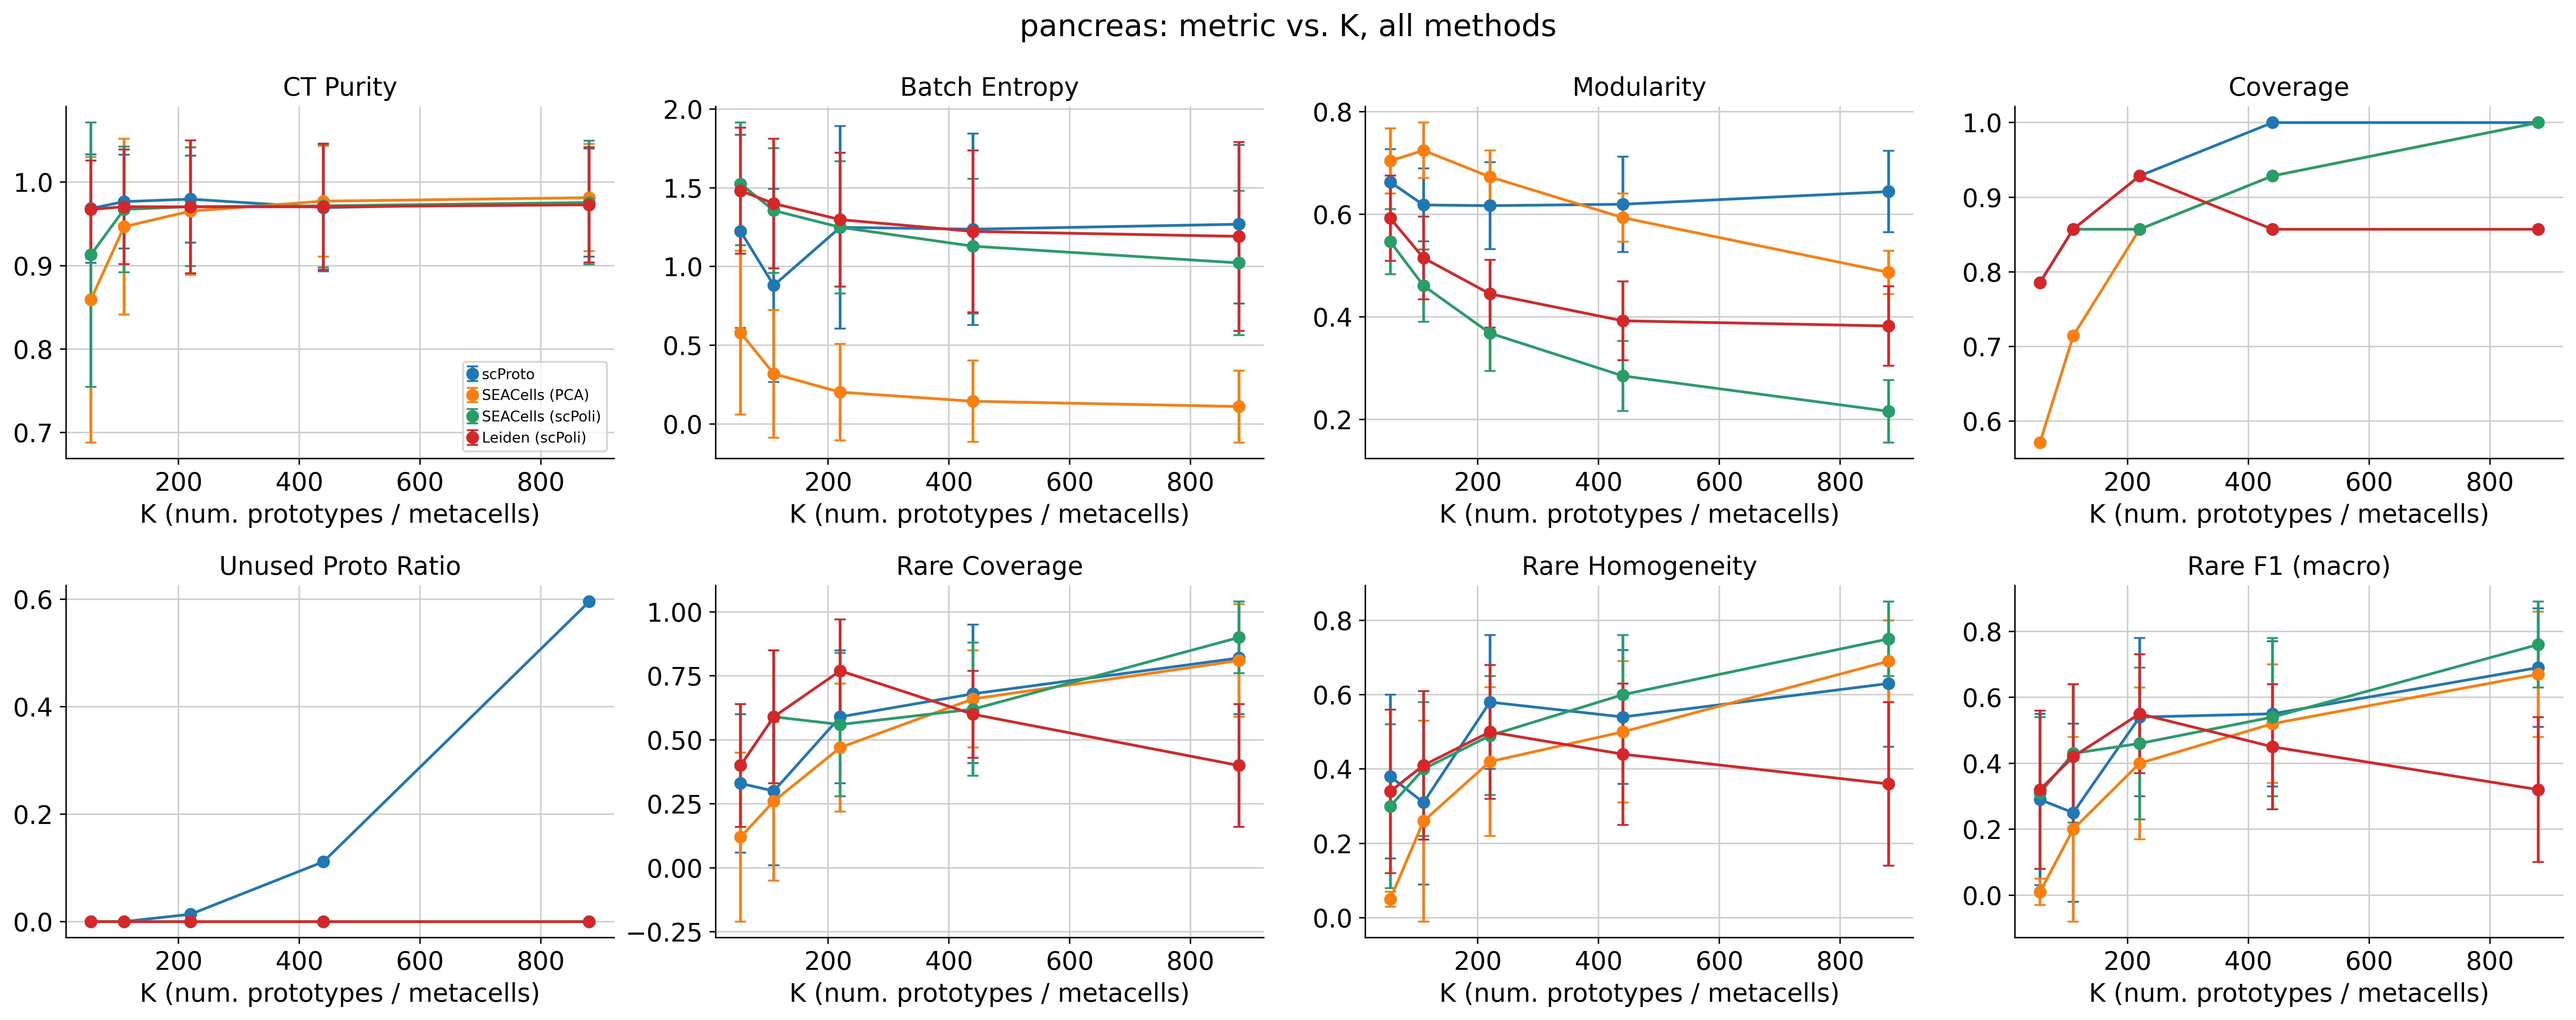

In [14]:
# --- K-sensitivity plots: one subplot per metric, one line per method, error bars = std ---
metrics_to_plot = [label for _, _, label in TASK1_PAIRS + RARE_PAIRS]
for ds_id in sweep_results:
    n = len(metrics_to_plot)
    fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(5 * ((n + 1) // 2), 8))
    axes = axes.ravel()
    for ax, label in zip(axes, metrics_to_plot):
        for method in METHODS:
            sub = df_long[(df_long.dataset == ds_id) & (df_long.metric == label) & (df_long.method == method)].sort_values('K')
            if sub['mean'].isna().all():
                continue
            ax.errorbar(sub['K'], sub['mean'], yerr=sub['std'].fillna(0), marker='o', label=method, capsize=3)
        ax.set_title(label)
        ax.set_xlabel('K (num. prototypes / metacells)')
    axes[0].legend(fontsize=8)
    fig.suptitle(f'{ds_id}: metric vs. K, all methods')
    fig.tight_layout()
    plt.show()

## Notes / next steps

- Claim being tested: scProto's curves should be relatively flat across the K grid (the
  community loss doing its job independent of exact K); a baseline like Leiden or SEACells is
  more likely to show real sensitivity, especially on rare-cell coverage/F1. If scProto is
  *also* sharply K-sensitive, report that honestly rather than hiding it.
- Modularity here is training-graph modularity (same circularity caveat as E1/E5 -- only
  scProto is trained against this exact graph). Purity/batch-entropy/rare-cell metrics
  (computed identically, post-hoc, for every method) carry the actual argument.
- Extending to lung / pbmc-immune: uncomment the "Run: Lung + PBMC" cell above -- no other
  code changes needed, `RUN_TAG`-prefixed folder names already avoid collisions across datasets.